<a href="https://colab.research.google.com/github/Malvocado/Machine_Learing_Final_Project/blob/main/Logistic_regression_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BMW Sales Classification — Logistic Regression


Predict whether a car has **High** or **Low** sales volume using car attributes.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, ConfusionMatrixDisplay,
    RocCurveDisplay
)

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120})
%matplotlib inline


## 1. Load & Inspect


In [ ]:
df = pd.read_csv("BMW_sales_data_after_processing.csv")
print(f"Shape: {df.shape}")
print(f"\nClass distribution:")
print(df['Sales_Classification'].value_counts())
print(f"\nClass proportions:")
print(df['Sales_Classification'].value_counts(normalize=True).round(3))
df.head(3)


Shape: (50000, 11)

Class distribution:
Sales_Classification
Low     34754
High    15246
Name: count, dtype: int64

Class proportions:
Sales_Classification
Low     0.695
High    0.305
Name: proportion, dtype: float64


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low


Dropping `Sales_Volume` — direct leakage (Classification is High iff Volume >= 7000).


In [ ]:
cat_cols = ["Model", "Region", "Color", "Fuel_Type", "Transmission"]
num_cols = ["Year", "Engine_Size_L", "Mileage_KM", "Price_USD"]

X = df[cat_cols + num_cols]

# Encode target to 0/1
le = LabelEncoder()
y = le.fit_transform(df["Sales_Classification"])
print(f"Classes: {list(le.classes_)} -> {list(range(len(le.classes_)))}")


Classes: ['High', 'Low'] -> [0, 1]


## 2. EDA — Compare High vs Low groups


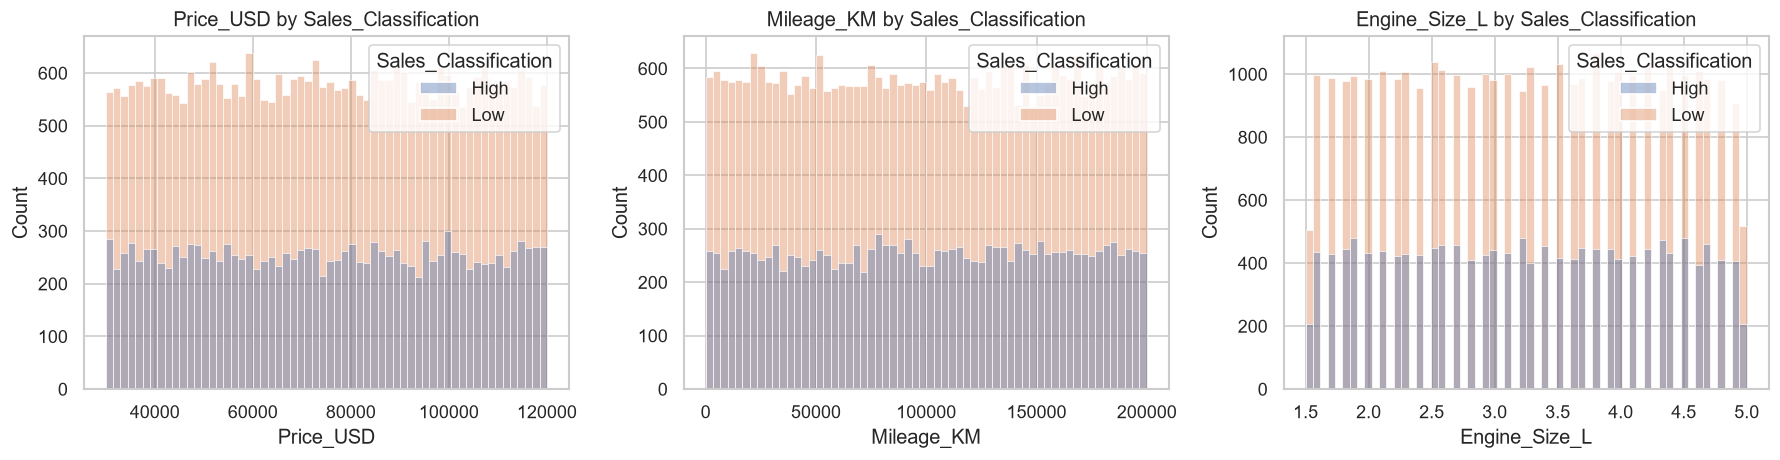

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Price_USD', 'Mileage_KM', 'Engine_Size_L']):
    sns.histplot(data=df, x=col, hue='Sales_Classification', bins=60, alpha=0.4, ax=ax)
    ax.set_title(f'{col} by Sales_Classification')
plt.tight_layout()
plt.show()


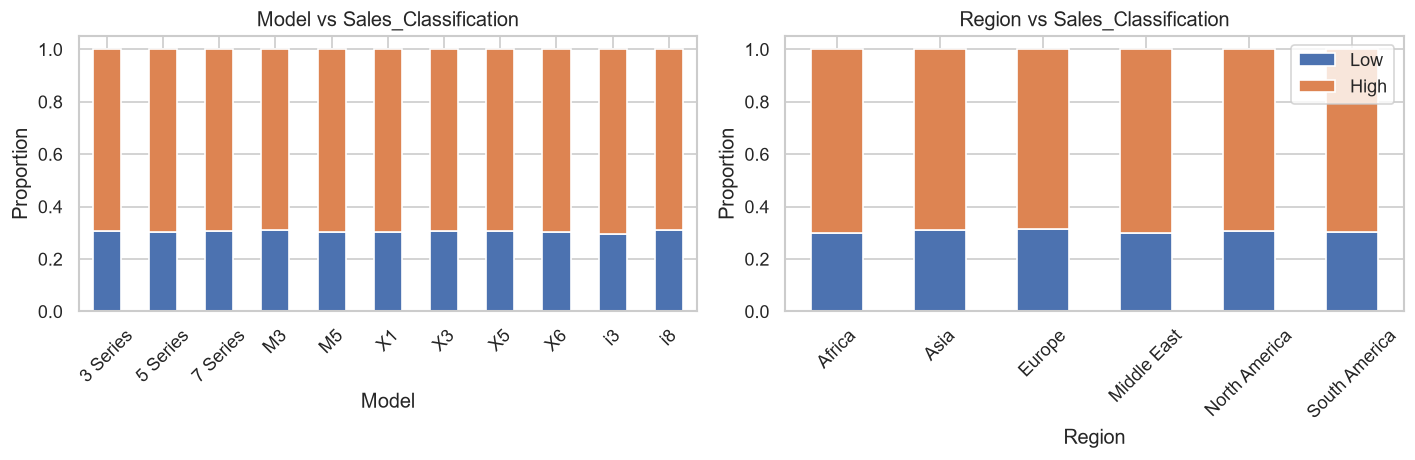

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['Model', 'Region']):
    ctab = pd.crosstab(df[col], df['Sales_Classification'], normalize='index')
    ctab.plot(kind='bar', stacked=True, ax=ax, legend=False)
    ax.set_title(f'{col} vs Sales_Classification')
    ax.set_ylabel('Proportion')
    ax.tick_params(axis='x', rotation=45)
axes[1].legend(['Low', 'High'], loc='upper right')
plt.tight_layout()
plt.show()


In [ ]:
print("=== Mean \u00b1 std by class ===")
for col in num_cols:
    g = df.groupby('Sales_Classification')[col]
    print(f"{col:15s}  Low: {g.mean()['Low']:>10.1f} \u00b1 {g.std()['Low']:>8.1f}   High: {g.mean()['High']:>10.1f} \u00b1 {g.std()['High']:>8.1f}")


=== Mean ± std by class ===
Year             Low:     2017.0 ±      4.3   High:     2017.1 ±      4.3
Engine_Size_L    Low:        3.2 ±      1.0   High:        3.2 ±      1.0
Mileage_KM       Low:   100054.7 ±  58020.0   High:   100882.8 ±  57759.9
Price_USD        Low:    75064.3 ±  25937.0   High:    74966.8 ±  26138.0


## 3. Train / Test Split (Stratified)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]:,}  Test: {X_test.shape[0]:,}")
print(f"Train class ratio: {(y_train == 0).mean():.3f} / {(y_train == 1).mean():.3f}")
print(f"Test  class ratio: {(y_test == 0).mean():.3f} / {(y_test == 1).mean():.3f}")


Train: 40,000  Test: 10,000
Train class ratio: 0.305 / 0.695
Test  class ratio: 0.305 / 0.695


## 4. Preprocessing + Logistic Regression


In [ ]:
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ("num", StandardScaler(), num_cols),
])

pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=42
    )),
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]  # prob of High


## 5. Evaluation


In [ ]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
baseline = max((y_test == 0).mean(), (y_test == 1).mean())

print(f"Accuracy:  {acc:.4f}  (majority-class baseline: {baseline:.4f})")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print()
print("Classification report:")
print(classification_report(y_test, y_pred, target_names=['Low', 'High']))


Accuracy:  0.5022  (majority-class baseline: 0.6951)
Precision: 0.6949
Recall:    0.5060
F1 Score:  0.5856
ROC-AUC:   0.5014

Classification report:
              precision    recall  f1-score   support

         Low       0.30      0.49      0.38      3049
        High       0.69      0.51      0.59      6951

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.48     10000
weighted avg       0.58      0.50      0.52     10000



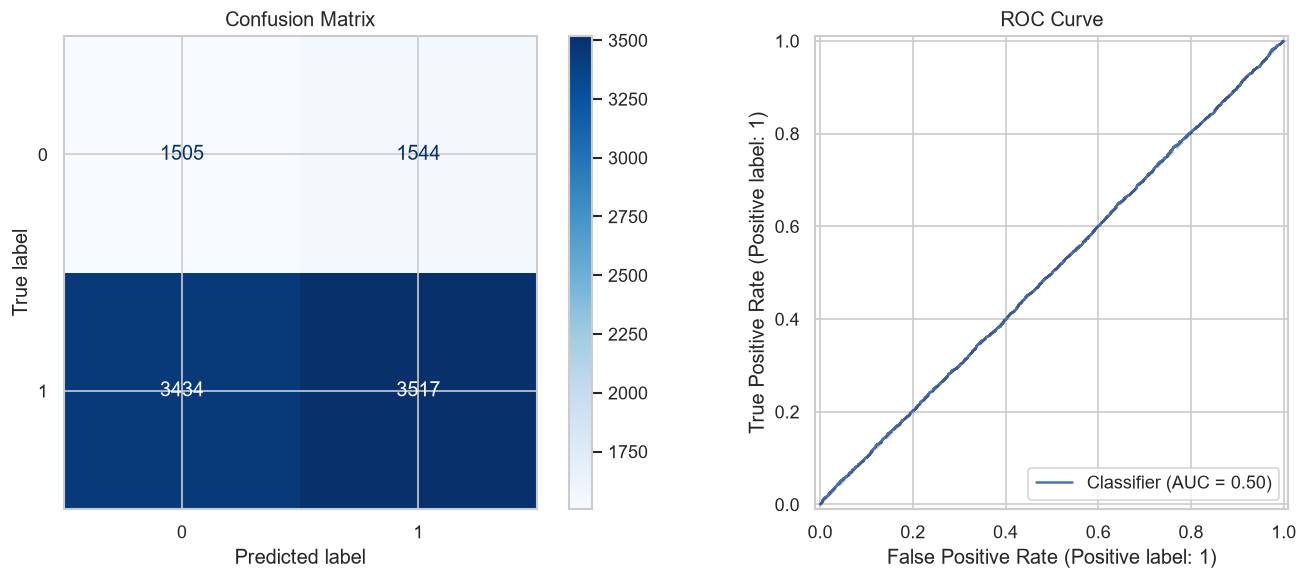

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix')

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_title('ROC Curve')

plt.tight_layout()
plt.show()


## 6. Coefficients (Feature Importance)


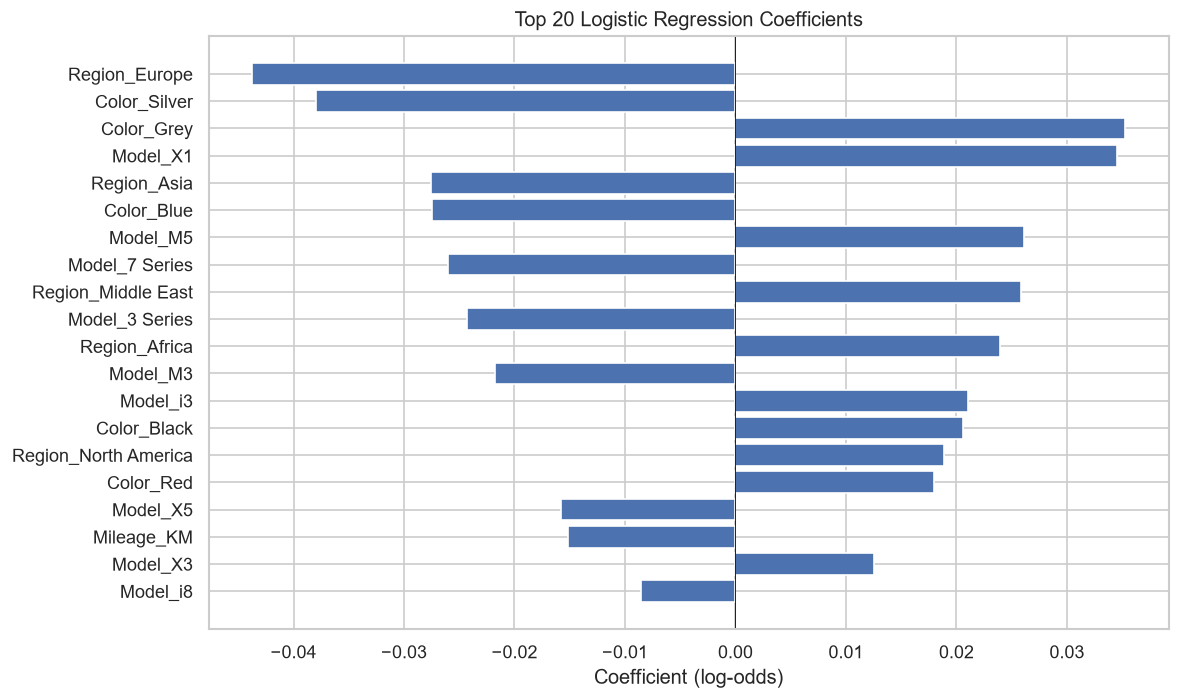

In [ ]:
clf = pipeline.named_steps["clf"]
prep = pipeline.named_steps["prep"]

cat_names = prep.named_transformers_["cat"].get_feature_names_out(cat_cols).tolist()
feature_names = cat_names + num_cols

coefs = clf.coef_[0]
idx = np.argsort(np.abs(coefs))[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
top_n = min(20, len(coefs))
ax.barh(range(top_n), coefs[idx][:top_n][::-1])
ax.set_yticks(range(top_n))
ax.set_yticklabels([feature_names[i] for i in idx[:top_n]][::-1])
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Top 20 Logistic Regression Coefficients')
plt.tight_layout()
plt.show()


In [ ]:
print("=" * 55)
print("  Logistic Regression on BMW Sales Classification")
print("=" * 55)
print(f"  Accuracy:              {acc:.4f}")
print(f"  Majority-class naive:  {baseline:.4f}")
print(f"  ROC-AUC:               {roc_auc:.4f}")
print(f"  Lift over naive:       {acc - baseline:+.4f}")
print("=" * 55)
if acc <= baseline + 0.01:
    print("  Conclusion: Model is no better than guessing majority.")
    print("  The features contain no signal for Sales_Classification.")
else:
    print("  Conclusion: Model shows slight signal above baseline.")
    print("  Note: Sales_Volume is dropped (direct leakage), so this tests")
    print("  whether car attributes alone predict sales classification.")


  Logistic Regression on BMW Sales Classification
  Accuracy:              0.5022
  Majority-class naive:  0.6951
  ROC-AUC:               0.5014
  Lift over naive:       -0.1929
  Conclusion: Model is no better than guessing majority.
  The features contain no signal for Sales_Classification.
